In [1]:
# Name = Dilpreet Kaur
# class = B.tech 

In [2]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression

In [3]:

import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## **1.READING AND UNDERSTAND THE DATA**

In [4]:
# read data
data=pd.read_csv('day.csv')

# showing our data
data.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,01-01-2018,1,0,1,0,1,1,2,14.110847,18.18125,80.5833,10.749882,331,654,985
1,2,02-01-2018,1,0,1,0,2,1,2,14.902598,17.68695,69.6087,16.652113,131,670,801
2,3,03-01-2018,1,0,1,0,3,1,1,8.050924,9.47025,43.7273,16.636703,120,1229,1349
3,4,04-01-2018,1,0,1,0,4,1,1,8.200000,10.60610,59.0435,10.739832,108,1454,1562
4,5,05-01-2018,1,0,1,0,5,1,1,9.305237,11.46350,43.6957,12.522300,82,1518,1600


In [5]:
# no. of columns and no. of rows
data.shape

(730, 16)

In [6]:
# checking zero terms
data.isnull().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

In [7]:
# it gives the summary of all numereic columns

data.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000
mean,365.500000,2.498630,0.500000,6.526027,0.028767,2.995890,0.690411,1.394521,20.319259,23.726322,62.765175,12.763620,849.249315,3658.757534,4508.006849
std,210.877136,1.110184,0.500343,3.450215,0.167266,2.000339,0.462641,0.544807,7.506729,8.150308,14.237589,5.195841,686.479875,1559.758728,1936.011647
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,2.424346,3.953480,0.000000,1.500244,2.000000,20.000000,22.000000
25%,183.250000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,13.811885,16.889713,52.000000,9.041650,316.250000,2502.250000,3169.750000
50%,365.500000,3.000000,0.500000,7.000000,0.000000,3.000000,1.000000,1.000000,20.465826,24.368225,62.625000,12.125325,717.000000,3664.500000,4548.500000
75%,547.750000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,26.880615,30.445775,72.989575,15.625589,1096.500000,4783.250000,5966.000000
max,730.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,35.328347,42.044800,97.250000,34.000021,3410.000000,6946.000000,8714.000000


In [8]:
# Rename the columns for more understanding
data.rename(columns={'yr':'year','mnth':'month','hum':'humidity','cnt':'count'},inplace=True)

#showing our data
data.head()

,instant,dteday,season,year,month,holiday,weekday,workingday,weathersit,temp,atemp,humidity,windspeed,casual,registered,count
0,1,01-01-2018,1,0,1,0,1,1,2,14.110847,18.18125,80.5833,10.749882,331,654,985
1,2,02-01-2018,1,0,1,0,2,1,2,14.902598,17.68695,69.6087,16.652113,131,670,801
2,3,03-01-2018,1,0,1,0,3,1,1,8.050924,9.47025,43.7273,16.636703,120,1229,1349
3,4,04-01-2018,1,0,1,0,4,1,1,8.200000,10.60610,59.0435,10.739832,108,1454,1562
4,5,05-01-2018,1,0,1,0,5,1,1,9.305237,11.46350,43.6957,12.522300,82,1518,1600


In [9]:
# it gives datatype of each column           # Another method of checking datatypes
                                             #data.dtypes
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 730 entries, 0 to 729
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     730 non-null    int64  
 1   dteday      730 non-null    object 
 2   season      730 non-null    int64  
 3   year        730 non-null    int64  
 4   month       730 non-null    int64  
 5   holiday     730 non-null    int64  
 6   weekday     730 non-null    int64  
 7   workingday  730 non-null    int64  
 8   weathersit  730 non-null    int64  
 9   temp        730 non-null    float64
 10  atemp       730 non-null    float64
 11  humidity    730 non-null    float64
 12  windspeed   730 non-null    float64
 13  casual      730 non-null    int64  
 14  registered  730 non-null    int64  
 15  count       730 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.4+ KB



# **2. DATA VISULISATION**



In [10]:
#IDENTIFY CATEGORICAL AND CONTINUOUS VALUES
data.nunique().sort_values()

#if number of unique values are less then it is a catagorical column
#if number of unique values are more then it is a continuous column



year            2
holiday         2
workingday      2
weathersit      3
season          4
weekday         7
month          12
temp          498
humidity      594
casual        605
windspeed     649
registered    678
atemp         689
count         695
instant       730
dteday        730
dtype: int64

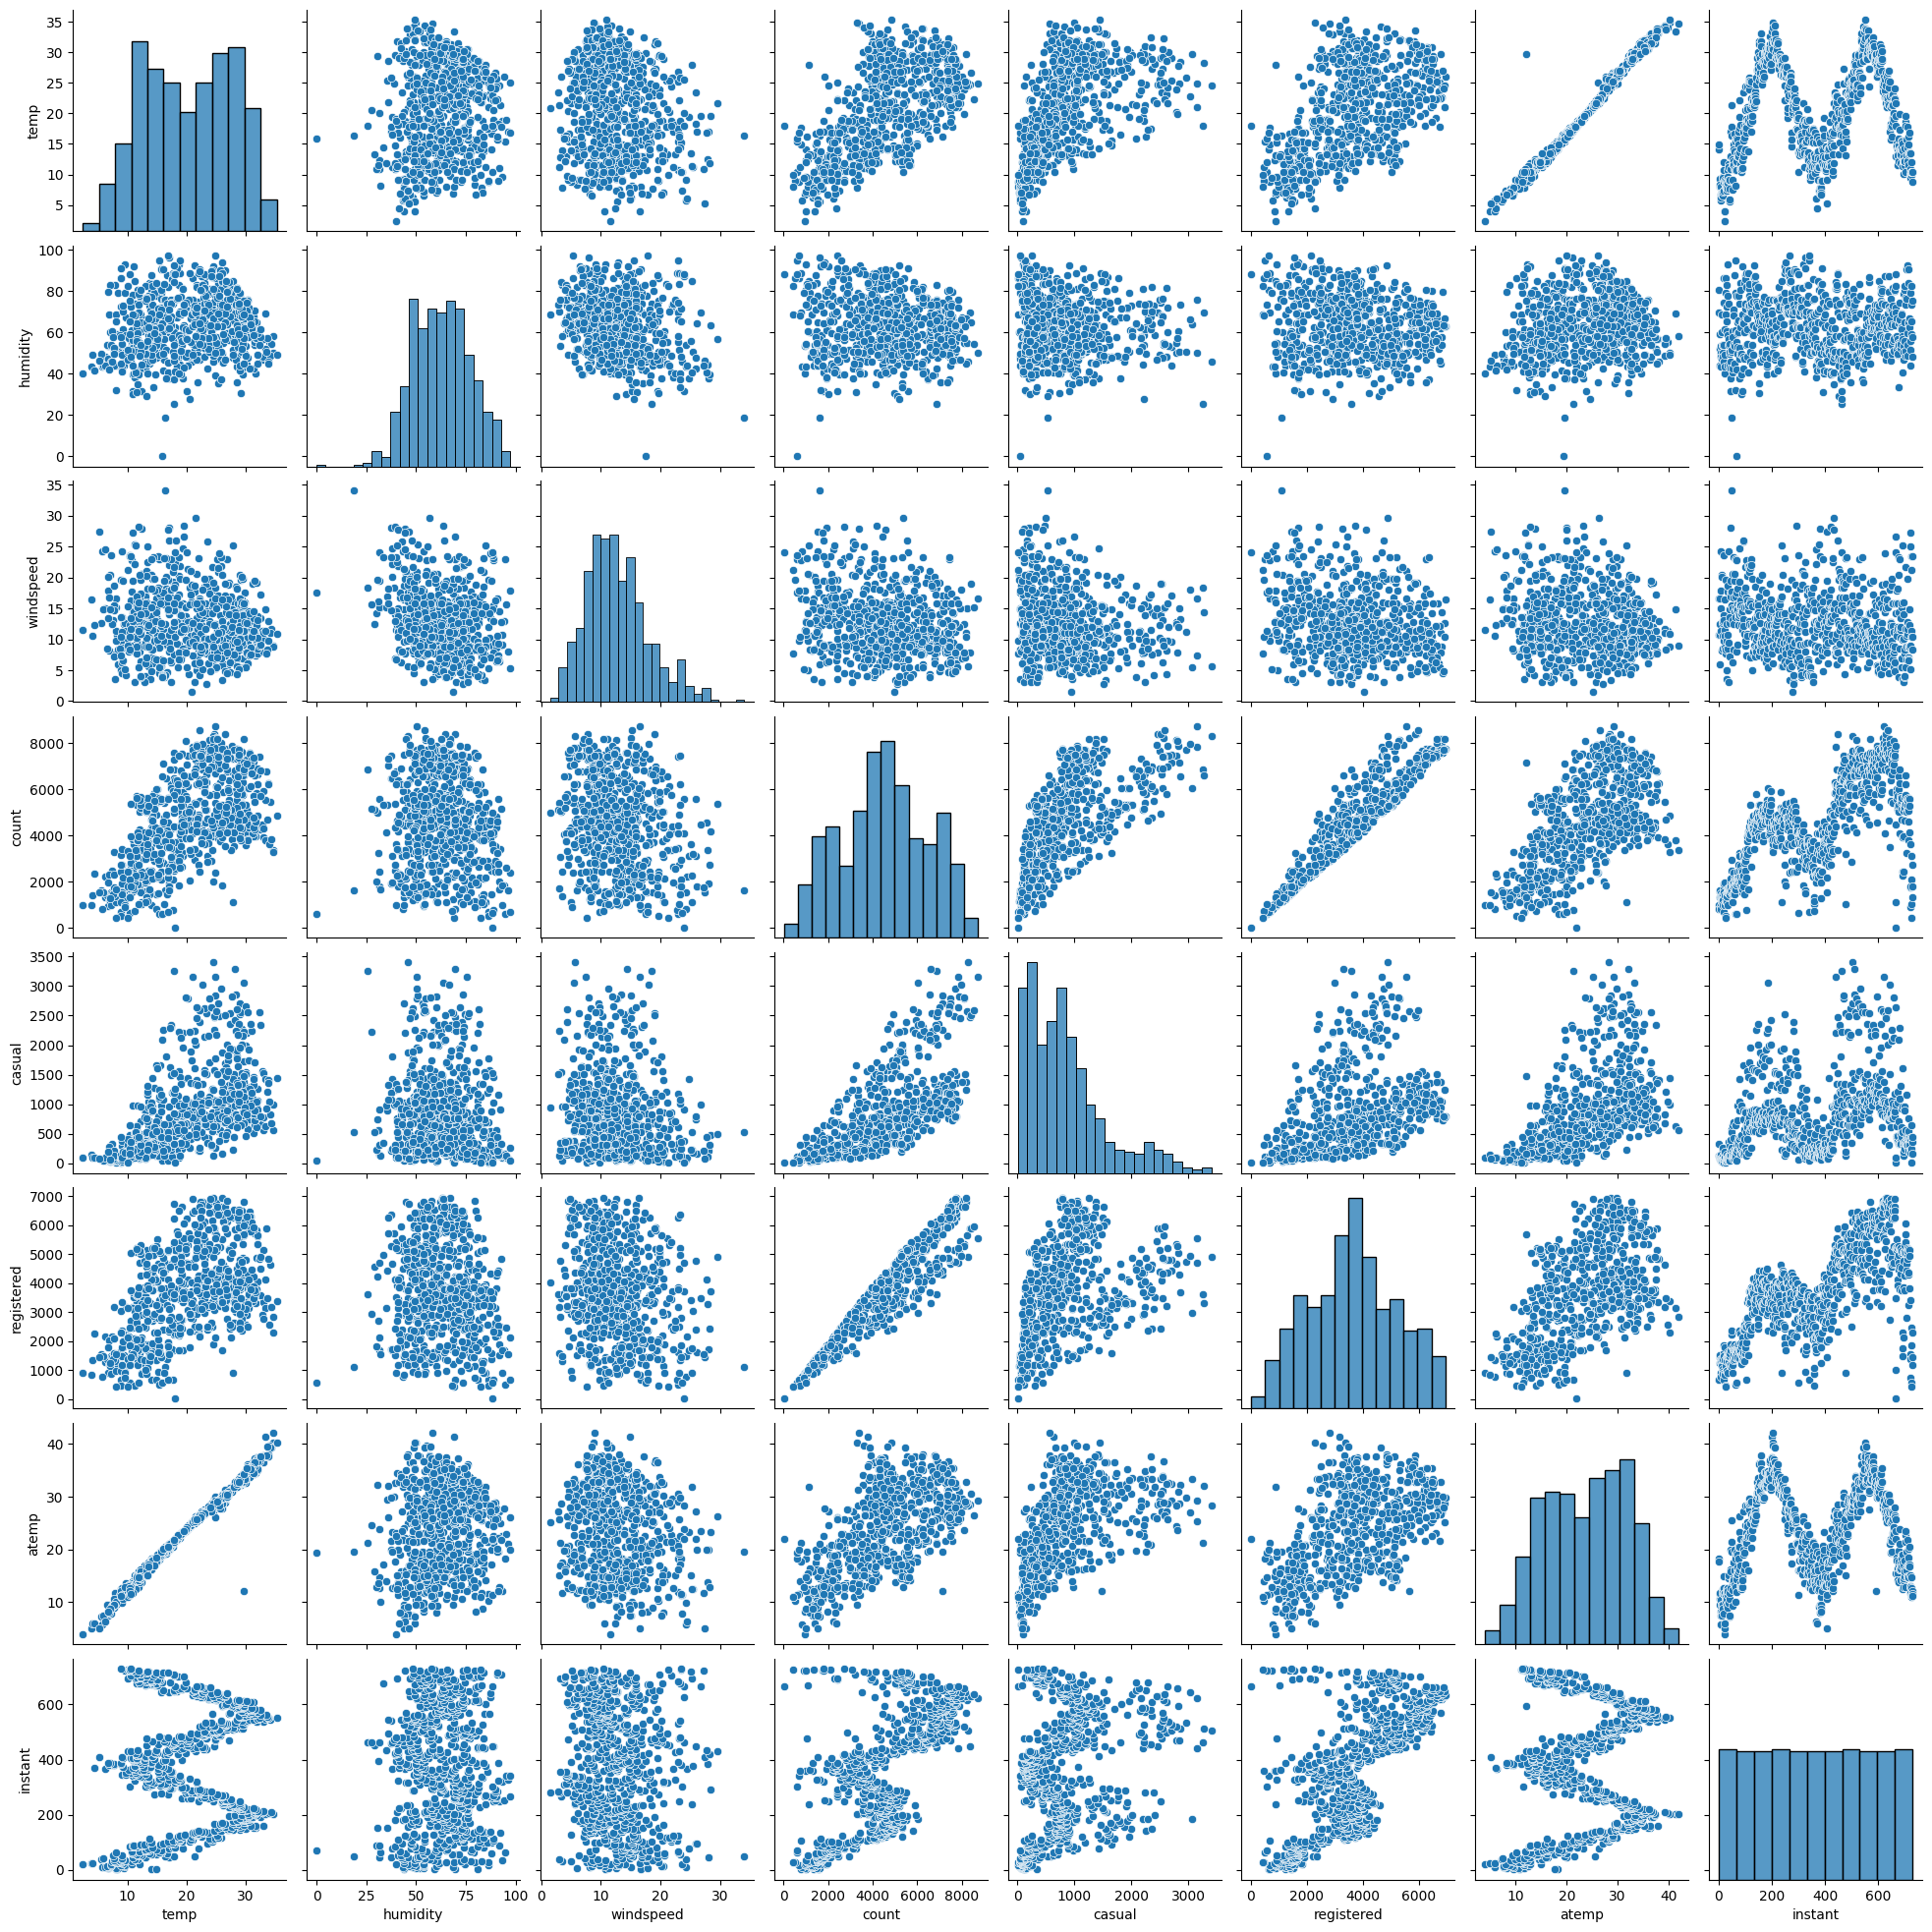

In [11]:
#pairplot for numeric varaibles
sns.pairplot(data,vars=["temp","humidity","windspeed","count","casual","registered","atemp","instant"])

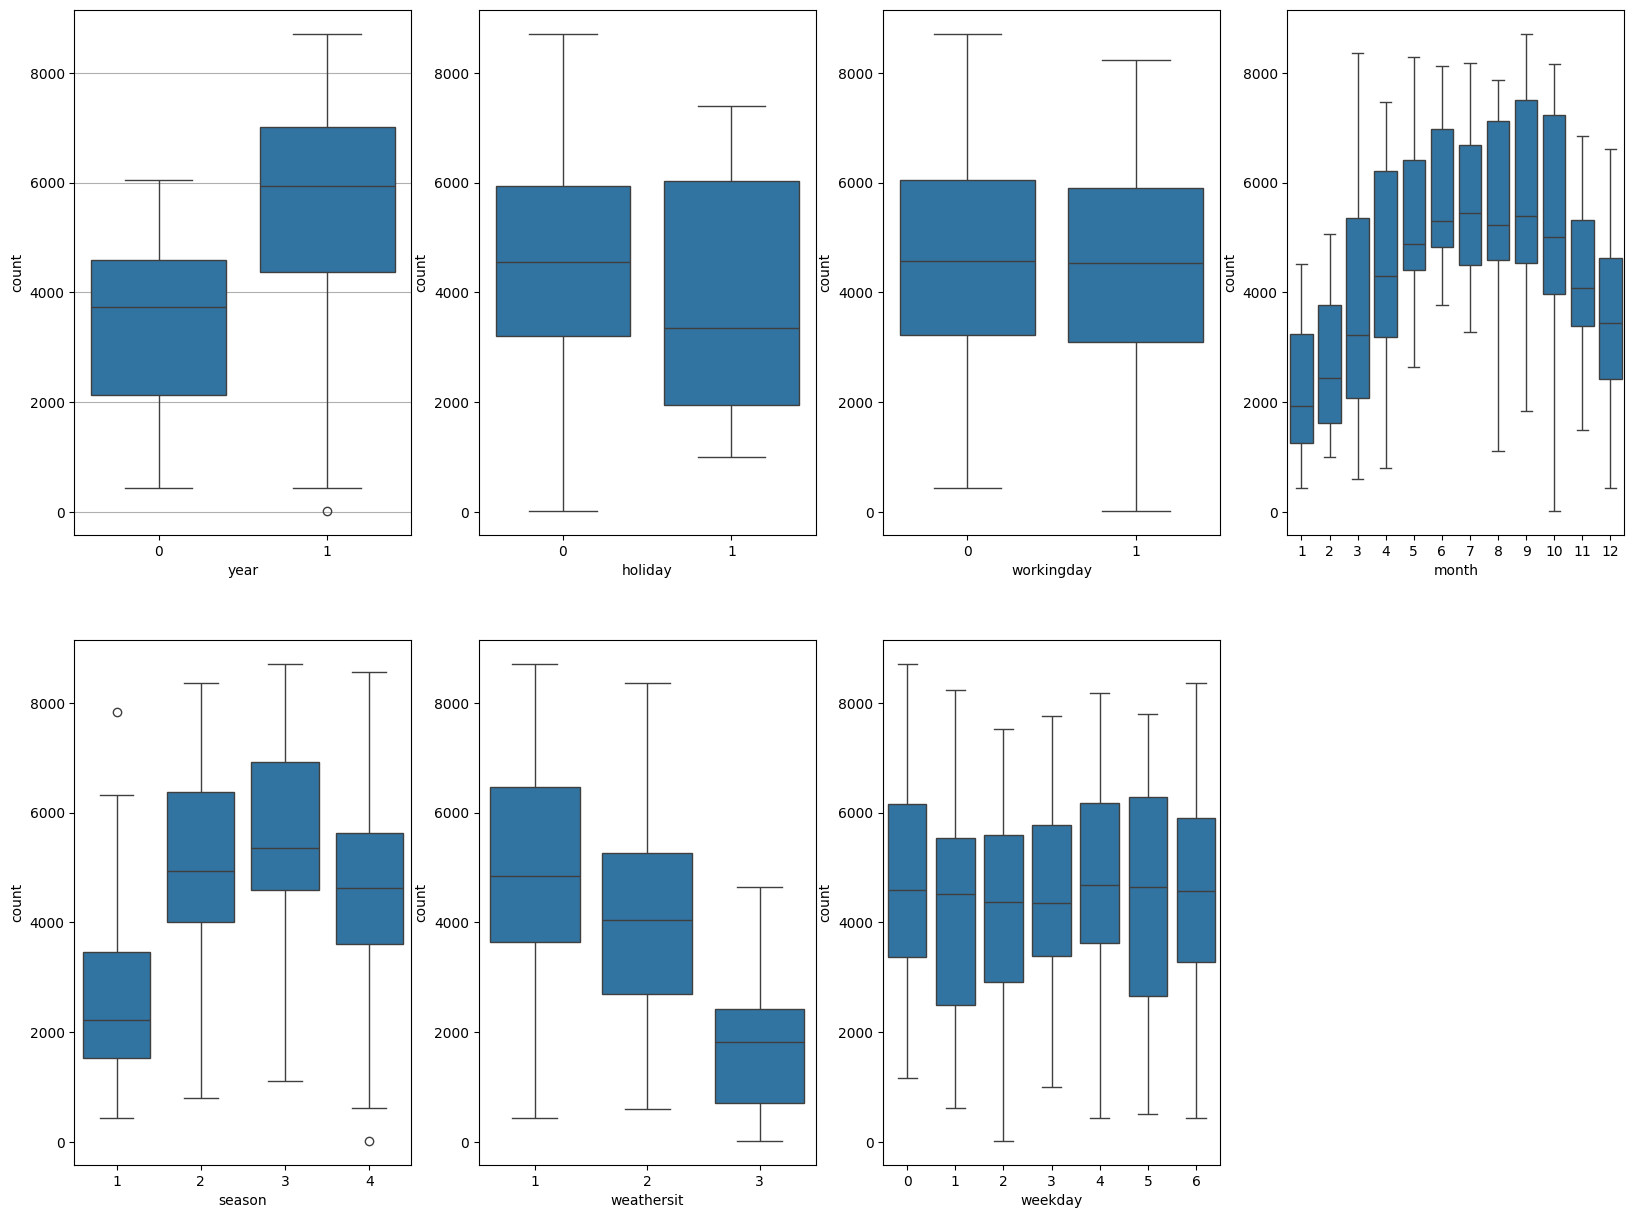

In [12]:
#GRAPH FOR CATEGORICAL VARAIBLES
plt.figure(figsize=(20,15))
ax=plt.subplot(2,4,1)
ax.grid(True)
sns.boxplot(x='year',y='count',data=data)
plt.subplot(2,4,2)
sns.boxplot(x='holiday',y='count',data=data)
plt.subplot(2,4,3)
sns.boxplot(x='workingday',y='count',data=data)
plt.subplot(2,4,4)
sns.boxplot(x='month',y='count',data=data)
plt.subplot(2,4,5)
sns.boxplot(x='season',y='count',data=data)
plt.subplot(2,4,6)
sns.boxplot(x='weathersit',y='count',data=data)
plt.subplot(2,4,7)
sns.boxplot(x='weekday',y='count',data=data)
plt.show()
         

### **1. SEASON**

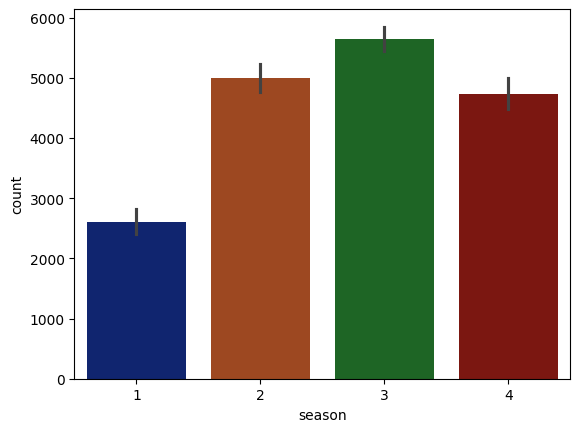

In [13]:
# relation between season and count
sns.barplot(x='season',y='count',data=data,palette="dark")
plt.show()

#bike rentals are more in winter(3) season

### **2.WEATHERSIT**

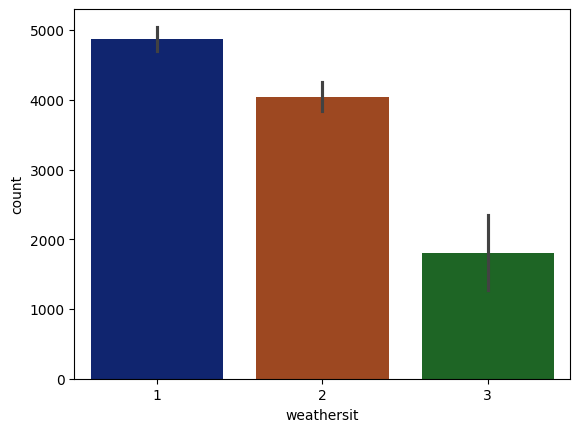

In [14]:
# relation between weathersit and count
sns.barplot(x='weathersit',y='count',data=data,palette="dark")
plt.show()
#bike rentals are more 1 weathersit

### **3. YEAR**

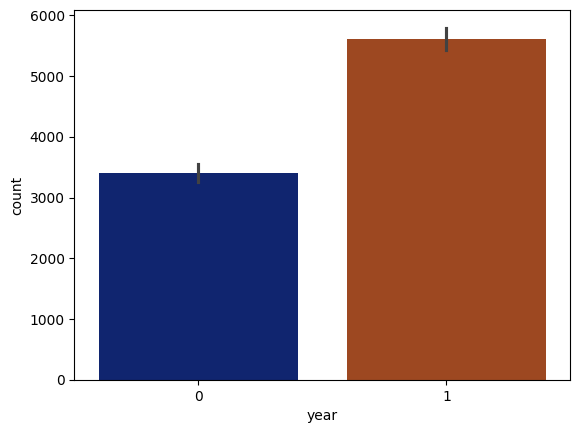

In [15]:
# relation between year and count
sns.barplot(x='year',y='count',data=data,palette="dark")
plt.show()

#bike rentels are more in 2nd year means 2019

### **MONTH**

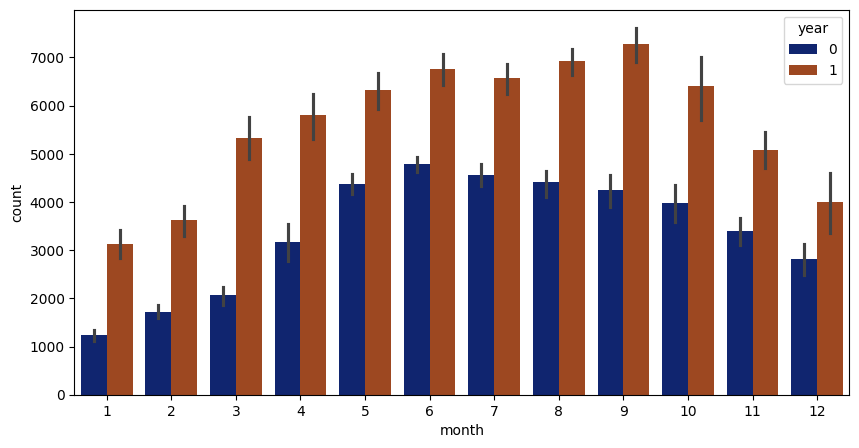

In [16]:
# relation between month and count
plt.figure(figsize=(10,5))
sns.barplot(x='month',y='count',hue='year',data=data,palette="dark")
plt.show()

#more bike rental are in August and September

### **5. TEMPERATURE**

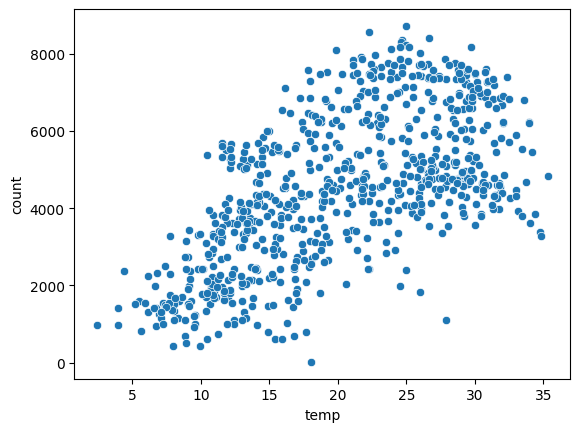

In [17]:
# relation between temp and count
sns.scatterplot(x='temp',y='count',data=data,palette="deep")
plt.show()

#bike rentals more at high temperatures

### **6. HUMIDITY**

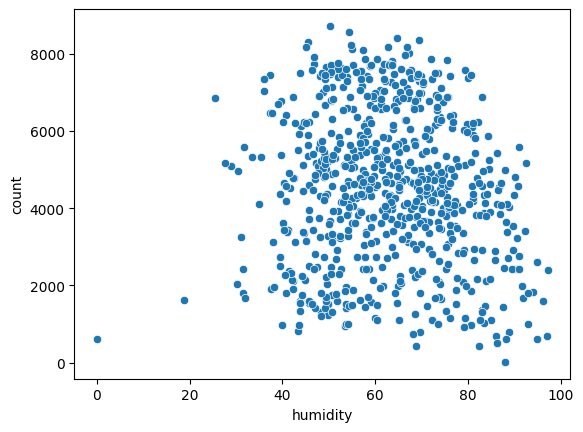

In [18]:
# relation between humidity and count
sns.scatterplot(x='humidity',y='count',data=data,palette="deep")
plt.show()

#bike rentals more at high humidity

In [19]:
data=data.drop(['dteday'],axis=1)
data

,instant,season,year,month,holiday,weekday,workingday,weathersit,temp,atemp,humidity,windspeed,casual,registered,count
0,1,1,0,1,0,1,1,2,14.110847,18.18125,80.5833,10.749882,331,654,985
1,2,1,0,1,0,2,1,2,14.902598,17.68695,69.6087,16.652113,131,670,801
2,3,1,0,1,0,3,1,1,8.050924,9.47025,43.7273,16.636703,120,1229,1349
3,4,1,0,1,0,4,1,1,8.200000,10.60610,59.0435,10.739832,108,1454,1562
4,5,1,0,1,0,5,1,1,9.305237,11.46350,43.6957,12.522300,82,1518,1600
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
725,726,1,1,12,0,5,1,2,10.420847,11.33210,65.2917,23.458911,247,1867,2114
726,727,1,1,12,0,6,0,2,10.386653,12.75230,59.0000,10.416557,644,2451,3095
727,728,1,1,12,0,0,0,2,10.386653,12.12000,75.2917,8.333661,159,1182,1341
728,729,1,1,12,0,1,1,1,10.489153,11.58500,48.3333,23.500518,364,1432,1796


### **HEATMAP**

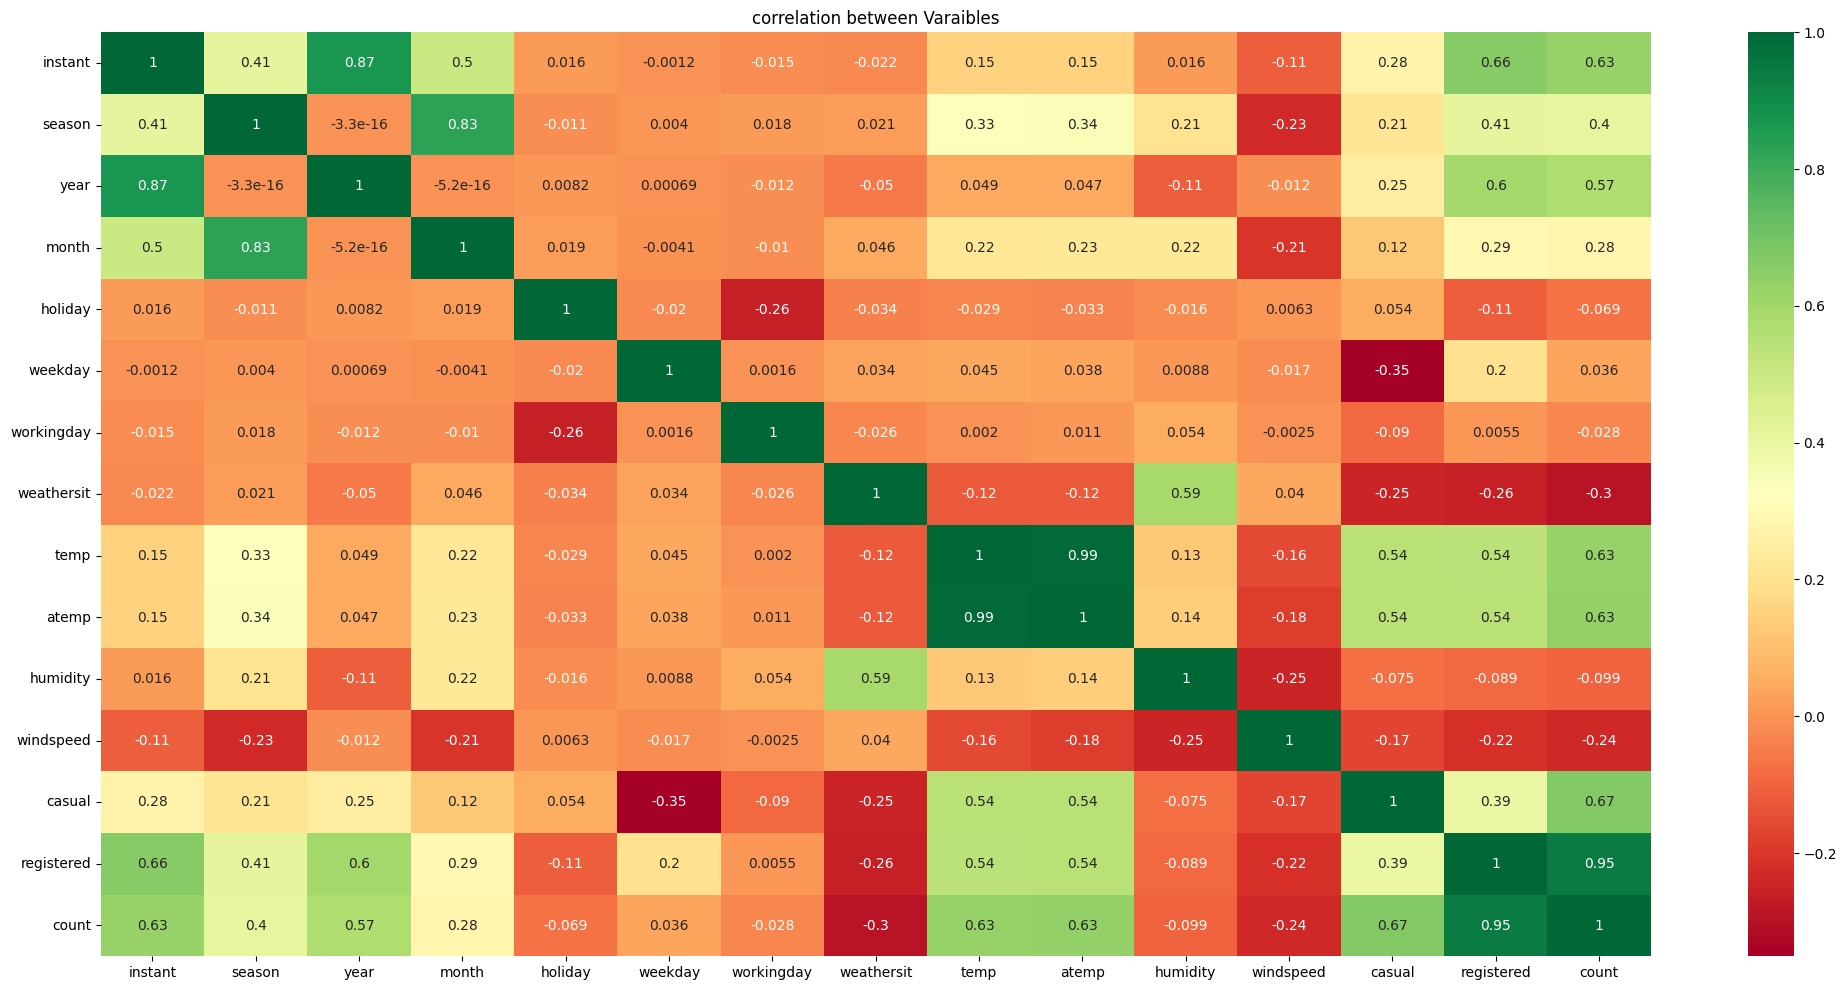

In [20]:
#Heatmap to see corelation between varaibles
plt.figure(figsize=(25,12))
sns.heatmap(data.corr(),cmap='RdYlGn',annot=True)
# annot= True means values are displayed inside the heatmap cells
plt.title("correlation between Varaibles")
plt.show()

## **3. DATA PREPARATION**

In [21]:
# convert such feature values into categorical string values 
data['season']=data.season.map({1:'spring',2:'summer',3:'winter',4:'autumn'})
#data['year']=data.year.map({0:'2018',1:'2019'})
data['month']=data.month.map({1:'Jan',2:'Feb',3:'March',4:'April',5:'May',6:'June',7:'July',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'})
data['weekday']=data.weekday.map({1:'Mon',2:'Tue',3:'Wed',4:'Thur',5:'Fri',6:'Sat',0:'Sun'})
data['weathersit']=data.weathersit.map({1:'Clear',2:'Cloudy',3:'Mist',4:'Snow'})

data.head()


,instant,season,year,month,holiday,weekday,workingday,weathersit,temp,atemp,humidity,windspeed,casual,registered,count
0,1,spring,0,Jan,0,Mon,1,Cloudy,14.110847,18.18125,80.5833,10.749882,331,654,985
1,2,spring,0,Jan,0,Tue,1,Cloudy,14.902598,17.68695,69.6087,16.652113,131,670,801
2,3,spring,0,Jan,0,Wed,1,Clear,8.050924,9.47025,43.7273,16.636703,120,1229,1349
3,4,spring,0,Jan,0,Thur,1,Clear,8.200000,10.60610,59.0435,10.739832,108,1454,1562
4,5,spring,0,Jan,0,Fri,1,Clear,9.305237,11.46350,43.6957,12.522300,82,1518,1600


In [22]:
#drop unnecessary columns
data=data.drop(['instant','casual','registered','atemp'],axis=1)
data.head()

,season,year,month,holiday,weekday,workingday,weathersit,temp,humidity,windspeed,count
0,spring,0,Jan,0,Mon,1,Cloudy,14.110847,80.5833,10.749882,985
1,spring,0,Jan,0,Tue,1,Cloudy,14.902598,69.6087,16.652113,801
2,spring,0,Jan,0,Wed,1,Clear,8.050924,43.7273,16.636703,1349
3,spring,0,Jan,0,Thur,1,Clear,8.200000,59.0435,10.739832,1562
4,spring,0,Jan,0,Fri,1,Clear,9.305237,43.6957,12.522300,1600


In [23]:
# DOING ONE HOT ENCODING ---as we have more than 3 classes
month=pd.get_dummies(data.month,dtype=int,drop_first=True)
weekday=pd.get_dummies(data.weekday,dtype=int,drop_first=True)
season=pd.get_dummies(data.season,dtype=int,drop_first=True)
weathersit=pd.get_dummies(data.weathersit,dtype=int,drop_first=True)

In [24]:
#concating this dataset
data_with_dummies=pd.concat([season,month,weekday,weathersit],axis=1)
data_with_dummies.head()

,spring,summer,winter,Aug,Dec,Feb,Jan,July,June,March,...,Oct,Sep,Mon,Sat,Sun,Thur,Tue,Wed,Cloudy,Mist
0,1,0,0,0,0,0,1,0,0,0,...,0,0,1,0,0,0,0,0,1,0
1,1,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,1,0,1,0
2,1,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,1,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,1,0,0,0,0
4,1,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [25]:
#data_with_dummies.info()  -- if you wwant to check again how many columns are there in dummies dataset only

In [26]:
#adding the dummies dataset with original dataset

data=pd.concat([data_with_dummies,data],axis=1)
data

,spring,summer,winter,Aug,Dec,Feb,Jan,July,June,March,...,year,month,holiday,weekday,workingday,weathersit,temp,humidity,windspeed,count
0,1,0,0,0,0,0,1,0,0,0,...,0,Jan,0,Mon,1,Cloudy,14.110847,80.5833,10.749882,985
1,1,0,0,0,0,0,1,0,0,0,...,0,Jan,0,Tue,1,Cloudy,14.902598,69.6087,16.652113,801
2,1,0,0,0,0,0,1,0,0,0,...,0,Jan,0,Wed,1,Clear,8.050924,43.7273,16.636703,1349
3,1,0,0,0,0,0,1,0,0,0,...,0,Jan,0,Thur,1,Clear,8.200000,59.0435,10.739832,1562
4,1,0,0,0,0,0,1,0,0,0,...,0,Jan,0,Fri,1,Clear,9.305237,43.6957,12.522300,1600
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
725,1,0,0,0,1,0,0,0,0,0,...,1,Dec,0,Fri,1,Cloudy,10.420847,65.2917,23.458911,2114
726,1,0,0,0,1,0,0,0,0,0,...,1,Dec,0,Sat,0,Cloudy,10.386653,59.0000,10.416557,3095
727,1,0,0,0,1,0,0,0,0,0,...,1,Dec,0,Sun,0,Cloudy,10.386653,75.2917,8.333661,1341
728,1,0,0,0,1,0,0,0,0,0,...,1,Dec,0,Mon,1,Clear,10.489153,48.3333,23.500518,1796


In [27]:
data.info()   #how many columns are there in resulted dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 730 entries, 0 to 729
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   spring      730 non-null    int32  
 1   summer      730 non-null    int32  
 2   winter      730 non-null    int32  
 3   Aug         730 non-null    int32  
 4   Dec         730 non-null    int32  
 5   Feb         730 non-null    int32  
 6   Jan         730 non-null    int32  
 7   July        730 non-null    int32  
 8   June        730 non-null    int32  
 9   March       730 non-null    int32  
 10  May         730 non-null    int32  
 11  Nov         730 non-null    int32  
 12  Oct         730 non-null    int32  
 13  Sep         730 non-null    int32  
 14  Mon         730 non-null    int32  
 15  Sat         730 non-null    int32  
 16  Sun         730 non-null    int32  
 17  Thur        730 non-null    int32  
 18  Tue         730 non-null    int32  
 19  Wed         730 non-null    i

In [28]:
#dropping the columns for which we have created dumies
data.drop(['season','month','weekday','weathersit'],axis=1,inplace=True)
data

,spring,summer,winter,Aug,Dec,Feb,Jan,July,June,March,...,Wed,Cloudy,Mist,year,holiday,workingday,temp,humidity,windspeed,count
0,1,0,0,0,0,0,1,0,0,0,...,0,1,0,0,0,1,14.110847,80.5833,10.749882,985
1,1,0,0,0,0,0,1,0,0,0,...,0,1,0,0,0,1,14.902598,69.6087,16.652113,801
2,1,0,0,0,0,0,1,0,0,0,...,1,0,0,0,0,1,8.050924,43.7273,16.636703,1349
3,1,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,1,8.200000,59.0435,10.739832,1562
4,1,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,1,9.305237,43.6957,12.522300,1600
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
725,1,0,0,0,1,0,0,0,0,0,...,0,1,0,1,0,1,10.420847,65.2917,23.458911,2114
726,1,0,0,0,1,0,0,0,0,0,...,0,1,0,1,0,0,10.386653,59.0000,10.416557,3095
727,1,0,0,0,1,0,0,0,0,0,...,0,1,0,1,0,0,10.386653,75.2917,8.333661,1341
728,1,0,0,0,1,0,0,0,0,0,...,0,0,0,1,0,1,10.489153,48.3333,23.500518,1796


In [29]:
data.info()  #how many columns are there in data after removing those columns for which we have created dummies

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 730 entries, 0 to 729
Data columns (total 29 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   spring      730 non-null    int32  
 1   summer      730 non-null    int32  
 2   winter      730 non-null    int32  
 3   Aug         730 non-null    int32  
 4   Dec         730 non-null    int32  
 5   Feb         730 non-null    int32  
 6   Jan         730 non-null    int32  
 7   July        730 non-null    int32  
 8   June        730 non-null    int32  
 9   March       730 non-null    int32  
 10  May         730 non-null    int32  
 11  Nov         730 non-null    int32  
 12  Oct         730 non-null    int32  
 13  Sep         730 non-null    int32  
 14  Mon         730 non-null    int32  
 15  Sat         730 non-null    int32  
 16  Sun         730 non-null    int32  
 17  Thur        730 non-null    int32  
 18  Tue         730 non-null    int32  
 19  Wed         730 non-null    i

In [30]:
data.shape

(730, 29)

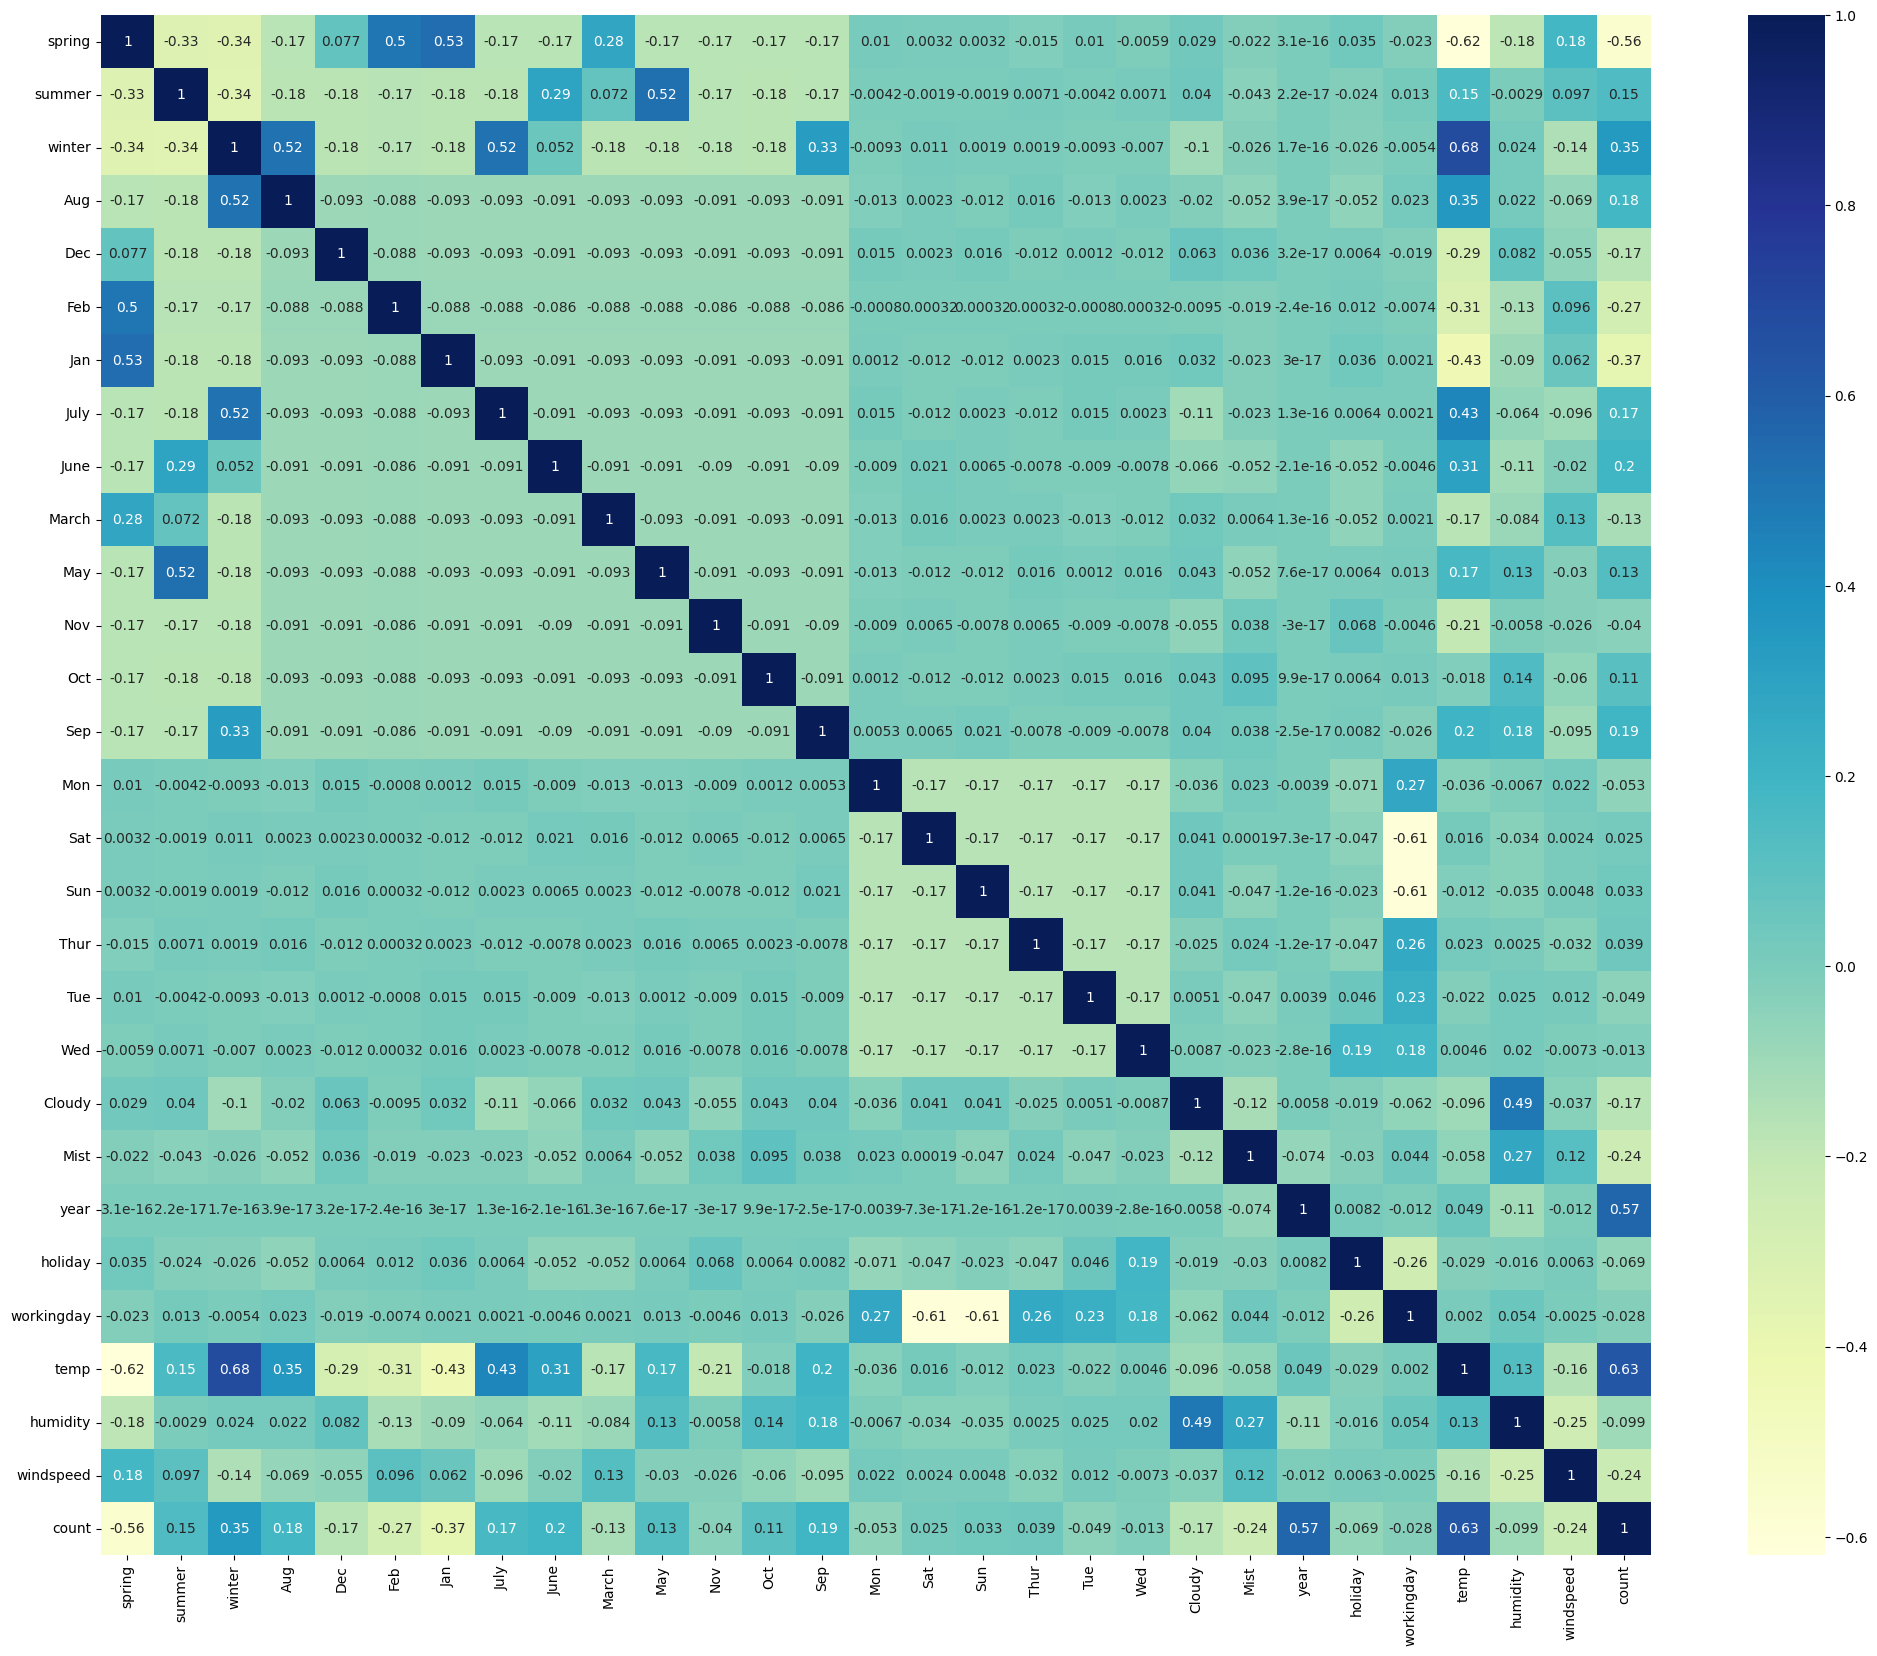

In [31]:
#checking correlation between varaibles using heatmap
plt.figure(figsize=(25,20))
sns.heatmap(data.corr(),cmap='YlGnBu',annot=True)
plt.show()

## **4. NORMALIZATION**

In [32]:
#normalization=(x-xmin)/(xmax-xmin)
# rescalling one or more features to ensure they fall within specific range

from sklearn.preprocessing import MinMaxScaler
# minmaxscaler--- scale data between (0,1)

In [33]:
scaler=MinMaxScaler()
cont_var=['temp','humidity','windspeed','count']
#fit on data
data[cont_var]=scaler.fit_transform(data[cont_var])
data.head()

,spring,summer,winter,Aug,Dec,Feb,Jan,July,June,March,...,Wed,Cloudy,Mist,year,holiday,workingday,temp,humidity,windspeed,count
0,1,0,0,0,0,0,1,0,0,0,...,0,1,0,0,0,1,0.355170,0.828620,0.284606,0.110792
1,1,0,0,0,0,0,1,0,0,0,...,0,1,0,0,0,1,0.379232,0.715771,0.466215,0.089623
2,1,0,0,0,0,0,1,0,0,0,...,1,0,0,0,0,1,0.171000,0.449638,0.465740,0.152669
3,1,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,1,0.175530,0.607131,0.284297,0.177174
4,1,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,1,0.209120,0.449313,0.339143,0.181546


In [34]:
#checking data after scaling
data.describe()

,spring,summer,winter,Aug,Dec,Feb,Jan,July,June,March,...,Wed,Cloudy,Mist,year,holiday,workingday,temp,humidity,windspeed,count
count,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,...,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000
mean,0.246575,0.252055,0.257534,0.084932,0.084932,0.076712,0.084932,0.084932,0.082192,0.084932,...,0.142466,0.336986,0.028767,0.500000,0.028767,0.690411,0.543852,0.645400,0.346568,0.516108
std,0.431313,0.434490,0.437576,0.278971,0.278971,0.266317,0.278971,0.278971,0.274845,0.278971,...,0.349767,0.473004,0.167266,0.500343,0.167266,0.462641,0.228140,0.146402,0.159873,0.222735
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.346084,0.534704,0.232045,0.362143
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.500000,0.000000,1.000000,0.548307,0.643959,0.326928,0.520766
75%,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.743261,0.750535,0.434629,0.683847
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## **5. SPLITING THE DATA INTO TRAINING AND TESTING DATA**

In [35]:
from sklearn.model_selection import train_test_split
data_train,data_test= train_test_split(data, train_size=0.7, random_state=100)


In [36]:
print(data_train.shape)
print(data_test.shape)

(510, 29)
(220, 29)


In [37]:
# the data on which we want to train our model
data_train.head()

,spring,summer,winter,Aug,Dec,Feb,Jan,July,June,March,...,Wed,Cloudy,Mist,year,holiday,workingday,temp,humidity,windspeed,count
576,0,0,1,0,0,0,0,1,0,0,...,1,0,0,1,0,1,0.815169,0.724079,0.294871,0.827658
426,1,0,0,0,0,0,0,0,0,1,...,0,1,0,1,0,0,0.442393,0.638817,0.285911,0.465255
728,1,0,0,0,1,0,0,0,0,0,...,0,0,0,1,0,1,0.245101,0.497001,0.676936,0.204096
482,0,1,0,0,0,0,0,0,0,0,...,0,1,0,1,0,0,0.395666,0.503427,0.221789,0.482973
111,0,1,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0.345824,0.750214,0.406392,0.191095


In [38]:
data_train.describe()

,spring,summer,winter,Aug,Dec,Feb,Jan,July,June,March,...,Wed,Cloudy,Mist,year,holiday,workingday,temp,humidity,windspeed,count
count,510.000000,510.000000,510.000000,510.000000,510.000000,510.000000,510.000000,510.000000,510.000000,510.000000,...,510.000000,510.000000,510.000000,510.000000,510.000000,510.000000,510.000000,510.000000,510.000000,510.000000
mean,0.243137,0.247059,0.262745,0.096078,0.084314,0.066667,0.088235,0.076471,0.076471,0.098039,...,0.135294,0.345098,0.029412,0.507843,0.025490,0.711765,0.537440,0.649087,0.348761,0.513499
std,0.429398,0.431725,0.440557,0.294988,0.278131,0.249689,0.283915,0.266010,0.266010,0.297660,...,0.342373,0.475867,0.169124,0.500429,0.157763,0.453386,0.225858,0.145534,0.162833,0.224421
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.041051,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.339853,0.537489,0.232053,0.356420
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.542596,0.652314,0.325631,0.518638
75%,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.735215,0.753214,0.438484,0.684710
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.997858,1.000000,1.000000


### **Dividing The Train Data Into X and y**

In [39]:
#dividing the train data into X and y
y_train=data_train.pop('count')
X_train=data_train
# pop removes count from data_trin and return it to y_train
#now our data dont have count

In [40]:
y_train.info()

<class 'pandas.core.series.Series'>
Index: 510 entries, 576 to 520
Series name: count
Non-Null Count  Dtype  
--------------  -----  
510 non-null    float64
dtypes: float64(1)
memory usage: 8.0 KB


In [41]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 510 entries, 576 to 520
Data columns (total 28 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   spring      510 non-null    int32  
 1   summer      510 non-null    int32  
 2   winter      510 non-null    int32  
 3   Aug         510 non-null    int32  
 4   Dec         510 non-null    int32  
 5   Feb         510 non-null    int32  
 6   Jan         510 non-null    int32  
 7   July        510 non-null    int32  
 8   June        510 non-null    int32  
 9   March       510 non-null    int32  
 10  May         510 non-null    int32  
 11  Nov         510 non-null    int32  
 12  Oct         510 non-null    int32  
 13  Sep         510 non-null    int32  
 14  Mon         510 non-null    int32  
 15  Sat         510 non-null    int32  
 16  Sun         510 non-null    int32  
 17  Thur        510 non-null    int32  
 18  Tue         510 non-null    int32  
 19  Wed         510 non-null    int3

# **6. BUILDING A LINEAR MODEL**

In [42]:
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import RFE

lm = LinearRegression()
lm.fit(X_train, y_train)

#RFE---Recursive feature elimination--select the most important features by recursively removing the least important one

rfe = RFE(estimator=lm,n_features_to_select=15)             
rfe = rfe.fit(X_train, y_train)

In [43]:
type(lm)

sklearn.linear_model._base.LinearRegression

In [44]:
list(zip(X_train.columns,rfe.support_,rfe.ranking_))  #used to combine three lists into the list of tuples
#True -- feature is selected(array of boolean values returned )
#rank-1--means most important feature

[('spring', True, 1),
 ('summer', True, 1),
 ('winter', True, 1),
 ('Aug', False, 9),
 ('Dec', True, 1),
 ('Feb', False, 2),
 ('Jan', True, 1),
 ('July', True, 1),
 ('June', False, 11),
 ('March', False, 14),
 ('May', False, 8),
 ('Nov', True, 1),
 ('Oct', False, 12),
 ('Sep', True, 1),
 ('Mon', False, 7),
 ('Sat', False, 4),
 ('Sun', False, 5),
 ('Thur', False, 13),
 ('Tue', False, 6),
 ('Wed', False, 10),
 ('Cloudy', True, 1),
 ('Mist', True, 1),
 ('year', True, 1),
 ('holiday', True, 1),
 ('workingday', False, 3),
 ('temp', True, 1),
 ('humidity', True, 1),
 ('windspeed', True, 1)]

In [45]:
col = X_train.columns[rfe.support_]
col    #selected features

Index(['spring', 'summer', 'winter', 'Dec', 'Jan', 'July', 'Nov', 'Sep',
       'Cloudy', 'Mist', 'year', 'holiday', 'temp', 'humidity', 'windspeed'],
      dtype='object')

In [46]:
#Columns where RFE support is False
X_train.columns[~rfe.support_]

Index(['Aug', 'Feb', 'June', 'March', 'May', 'Oct', 'Mon', 'Sat', 'Sun',
       'Thur', 'Tue', 'Wed', 'workingday'],
      dtype='object')

In [47]:
#installing library

In [48]:
!pip install statsmodels  

In [49]:
import statsmodels.api as sm
#ols is a model of this library


In [50]:
# Creating X_test dataframe with RFE selected variables
X_train_rfe = X_train[col]

In [51]:
# adding constant to x_train
X_train_rfe=sm.add_constant(X_train_rfe)


In [52]:
X_train_rfe

,const,spring,summer,winter,Dec,Jan,July,Nov,Sep,Cloudy,Mist,year,holiday,temp,humidity,windspeed
576,1.0,0,0,1,0,0,1,0,0,0,0,1,0,0.815169,0.724079,0.294871
426,1.0,1,0,0,0,0,0,0,0,1,0,1,0,0.442393,0.638817,0.285911
728,1.0,1,0,0,1,0,0,0,0,0,0,1,0,0.245101,0.497001,0.676936
482,1.0,0,1,0,0,0,0,0,0,1,0,1,0,0.395666,0.503427,0.221789
111,1.0,0,1,0,0,0,0,0,0,1,0,0,0,0.345824,0.750214,0.406392
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
578,1.0,0,0,1,0,0,0,0,0,0,0,1,0,0.863973,0.678234,0.220508
53,1.0,1,0,0,0,0,0,0,0,0,0,0,0,0.202618,0.435006,0.147857
350,1.0,0,0,0,1,0,0,0,0,1,0,0,0,0.248216,0.576692,0.455140
79,1.0,0,1,0,0,0,0,0,0,1,0,0,0,0.462664,0.758243,0.549180


In [53]:
#fit the model
lm=sm.OLS(y_train,X_train_rfe).fit()

In [54]:
print(lm.summary())
#t=t-statistic ----shows how important each feature is predicting the target var
#------if t-value is far away from zero then featur is very important
#------negative t-value means as the feature increases,the target value decreases

#p>|t|----if p-value is less than t then the reult meets significant criteria
#---------p-vaue is probability of obtaining the result

#std err ----it measure the uncertainity with the estimated coefficient in regression model
#[0.025  0.975] --represent that the range within the true coefficient lies with 95% lwevel of confidence



                            OLS Regression Results                            
Dep. Variable:                  count   R-squared:                       0.845
Model:                            OLS   Adj. R-squared:                  0.840
Method:                 Least Squares   F-statistic:                     179.4
Date:                Mon, 15 Jul 2024   Prob (F-statistic):          8.15e-189
Time:                        16:22:34   Log-Likelihood:                 514.19
No. Observations:                 510   AIC:                            -996.4
Df Residuals:                     494   BIC:                            -928.6
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.4297      0.033     13.091      0.0

In [55]:
type(lm)

statsmodels.regression.linear_model.RegressionResultsWrapper

VIF
 

In [56]:
#Drop the constant term 
X_train_rfe = X_train_rfe.drop(['const'], axis=1)

In [57]:
# Calculate the VIFs for the new model
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = pd.DataFrame()
X = X_train_rfe
vif['Features'] = X.columns
vif['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif['VIF'] = round(vif['VIF'], 2)
vif = vif.sort_values(by = "VIF", ascending = False)
vif

,Features,VIF
12,temp,24.73
13,humidity,23.45
2,winter,5.39
14,windspeed,5.27
0,spring,3.18
1,summer,3.16
8,Cloudy,2.24
10,year,2.07
4,Jan,1.78
6,Nov,1.67


In [58]:
X_train_new2 = X_train_rfe.drop(["windspeed"], axis = 1)

In [59]:
X_train_new2

,spring,summer,winter,Dec,Jan,July,Nov,Sep,Cloudy,Mist,year,holiday,temp,humidity
576,0,0,1,0,0,1,0,0,0,0,1,0,0.815169,0.724079
426,1,0,0,0,0,0,0,0,1,0,1,0,0.442393,0.638817
728,1,0,0,1,0,0,0,0,0,0,1,0,0.245101,0.497001
482,0,1,0,0,0,0,0,0,1,0,1,0,0.395666,0.503427
111,0,1,0,0,0,0,0,0,1,0,0,0,0.345824,0.750214
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
578,0,0,1,0,0,0,0,0,0,0,1,0,0.863973,0.678234
53,1,0,0,0,0,0,0,0,0,0,0,0,0.202618,0.435006
350,0,0,0,1,0,0,0,0,1,0,0,0,0.248216,0.576692
79,0,1,0,0,0,0,0,0,1,0,0,0,0.462664,0.758243


Rebuilding the model without 'windspeed'

In [60]:
#Build a model
X_train_lm2 = sm.add_constant(X_train_new2)
lm2 = sm.OLS(y_train,X_train_lm2).fit()
print(lm2.summary())

                            OLS Regression Results                            
Dep. Variable:                  count   R-squared:                       0.828
Model:                            OLS   Adj. R-squared:                  0.823
Method:                 Least Squares   F-statistic:                     170.4
Date:                Mon, 15 Jul 2024   Prob (F-statistic):          5.79e-179
Time:                        16:22:34   Log-Likelihood:                 487.96
No. Observations:                 510   AIC:                            -945.9
Df Residuals:                     495   BIC:                            -882.4
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.3159      0.030     10.393      0.0

In [61]:
#Drop the constant term
X_train_lm2 = X_train_lm2.drop(['const'], axis=1)

In [62]:
# Calculate the VIFs for EACH FEATURE
vif = pd.DataFrame()
X = X_train_new2
vif['Features'] = X.columns
#calculate vif
vif['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif['VIF'] = round(vif['VIF'], 2)  #rounding off the value upto 2 digits
vif = vif.sort_values(by = "VIF", ascending = False)
vif

,Features,VIF
12,temp,23.66
13,humidity,23.40
2,winter,5.39
1,summer,2.97
0,spring,2.59
8,Cloudy,2.24
10,year,2.06
4,Jan,1.77
5,July,1.61
6,Nov,1.57


Jan have high p-value and low VIF; can be dropped

Rebuliding the model without Jan

In [63]:
#Drop the november column
X_train_new3=X_train_lm2.drop(['Jan'],axis=1)

In [64]:
# Adding a constant variable 
X_train_lm3 = sm.add_constant(X_train_new3)
lm3 = sm.OLS(y_train,X_train_lm3).fit()
print(lm3.summary())

                            OLS Regression Results                            
Dep. Variable:                  count   R-squared:                       0.827
Model:                            OLS   Adj. R-squared:                  0.823
Method:                 Least Squares   F-statistic:                     182.9
Date:                Mon, 15 Jul 2024   Prob (F-statistic):          1.25e-179
Time:                        16:22:34   Log-Likelihood:                 486.83
No. Observations:                 510   AIC:                            -945.7
Df Residuals:                     496   BIC:                            -886.4
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.3092      0.030     10.274      0.0

In [65]:
#Drop constant 
X_train_lm3=X_train_lm3.drop(['const'],axis=1)

In [66]:
# Calculate the VIFs for the new model
vif = pd.DataFrame()
X = X_train_new3
vif['Features'] = X.columns
vif['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif['VIF'] = round(vif['VIF'], 2)
vif = vif.sort_values(by = "VIF", ascending = False)
vif

,Features,VIF
12,humidity,21.67
11,temp,21.64
2,winter,5.29
1,summer,2.96
7,Cloudy,2.23
0,spring,2.21
9,year,2.05
4,July,1.61
5,Nov,1.56
6,Sep,1.45


'humidity' variable can be dropped as its insignificant by looking at very high VIF

Rebuilding the model without humidity

In [67]:
#Drop July
X_train_new4= X_train_lm3.drop(['humidity'], axis=1)

In [68]:
#Build a model
X_train_lm4=sm.add_constant(X_train_new4)
lm4=sm.OLS(y_train,X_train_lm4).fit()
print(lm4.summary())

                            OLS Regression Results                            
Dep. Variable:                  count   R-squared:                       0.825
Model:                            OLS   Adj. R-squared:                  0.821
Method:                 Least Squares   F-statistic:                     195.6
Date:                Mon, 15 Jul 2024   Prob (F-statistic):          1.76e-179
Time:                        16:22:34   Log-Likelihood:                 483.73
No. Observations:                 510   AIC:                            -941.5
Df Residuals:                     497   BIC:                            -886.4
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2618      0.023     11.260      0.0

In [69]:
#Drop constant
X_train_lm4= X_train_lm4.drop(['const'], axis=1)

In [70]:
# Calculate the VIFs for the new model
vif = pd.DataFrame()
X =X_train_new4
vif['Features'] = X.columns
vif['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif['VIF'] = round(vif['VIF'], 2)
vif = vif.sort_values(by = "VIF", ascending = False)
vif

,Features,VIF
11,temp,8.89
2,winter,5.12
1,summer,2.93
9,year,2.05
4,July,1.60
0,spring,1.54
7,Cloudy,1.51
6,Sep,1.40
5,Nov,1.35
3,Dec,1.17


Dec column can be dropped due to its p value and low VIF

In [71]:
#Drop July
X_train_new5=X_train_lm4.drop(['Dec'], axis=1)


In [72]:
#Building a model
X_train_lm5= sm.add_constant(X_train_new5)
lm5=sm.OLS(y_train,X_train_lm5).fit()
print(lm5.summary())

                            OLS Regression Results                            
Dep. Variable:                  count   R-squared:                       0.825
Model:                            OLS   Adj. R-squared:                  0.821
Method:                 Least Squares   F-statistic:                     212.8
Date:                Mon, 15 Jul 2024   Prob (F-statistic):          3.23e-180
Time:                        16:22:34   Log-Likelihood:                 482.69
No. Observations:                 510   AIC:                            -941.4
Df Residuals:                     498   BIC:                            -890.6
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2458      0.020     12.052      0.0

In [73]:
#Drop the constant
X_train_lm5=X_train_lm5.drop(['const'],axis=1)

In [74]:
# Calculate the VIFs for the new model
vif = pd.DataFrame()
X = X_train_new5
vif['Features'] = X.columns
vif['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif['VIF'] = round(vif['VIF'], 2)
vif = vif.sort_values(by = "VIF", ascending = False)
vif

,Features,VIF
10,temp,8.28
2,winter,4.81
1,summer,2.72
8,year,2.04
3,July,1.59
0,spring,1.53
6,Cloudy,1.50
5,Sep,1.40
4,Nov,1.31
9,holiday,1.06


Winter have high VIF and negative correlation with count, drop it

In [75]:
#Drop windspeed
X_train_new6= X_train_lm5.drop(['winter'], axis=1)

In [76]:
X_train_new6

,spring,summer,July,Nov,Sep,Cloudy,Mist,year,holiday,temp
576,0,0,1,0,0,0,0,1,0,0.815169
426,1,0,0,0,0,1,0,1,0,0.442393
728,1,0,0,0,0,0,0,1,0,0.245101
482,0,1,0,0,0,1,0,1,0,0.395666
111,0,1,0,0,0,1,0,0,0,0.345824
...,...,...,...,...,...,...,...,...,...,...
578,0,0,0,0,0,0,0,1,0,0.863973
53,1,0,0,0,0,0,0,0,0,0.202618
350,0,0,0,0,0,1,0,0,0,0.248216
79,0,1,0,0,0,1,0,0,0,0.462664


In [77]:
#Build a model
X_train_lm6=sm.add_constant(X_train_new6)
lm6=sm.OLS(y_train,X_train_lm6).fit()
print(lm6.summary())

                            OLS Regression Results                            
Dep. Variable:                  count   R-squared:                       0.816
Model:                            OLS   Adj. R-squared:                  0.813
Method:                 Least Squares   F-statistic:                     221.7
Date:                Mon, 15 Jul 2024   Prob (F-statistic):          1.97e-176
Time:                        16:22:35   Log-Likelihood:                 470.93
No. Observations:                 510   AIC:                            -919.9
Df Residuals:                     499   BIC:                            -873.3
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2631      0.021     12.815      0.0

In [78]:
#Drop constant
X_train_lm6= X_train_lm6.drop(['const'], axis=1)

In [79]:
# Calculate the VIFs for the new model
vif = pd.DataFrame()
X =X_train_new6
vif['Features'] = X.columns
vif['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif['VIF'] = round(vif['VIF'], 2)
vif = vif.sort_values(by = "VIF", ascending = False)
vif

,Features,VIF
9,temp,3.80
7,year,2.03
1,summer,1.71
5,Cloudy,1.50
2,July,1.48
4,Sep,1.33
0,spring,1.30
3,Nov,1.16
8,holiday,1.06
6,Mist,1.04


STEP 6--ANALYSIS OF TRAIN DATA

In [80]:
X_train_lm6

,spring,summer,July,Nov,Sep,Cloudy,Mist,year,holiday,temp
576,0,0,1,0,0,0,0,1,0,0.815169
426,1,0,0,0,0,1,0,1,0,0.442393
728,1,0,0,0,0,0,0,1,0,0.245101
482,0,1,0,0,0,1,0,1,0,0.395666
111,0,1,0,0,0,1,0,0,0,0.345824
...,...,...,...,...,...,...,...,...,...,...
578,0,0,0,0,0,0,0,1,0,0.863973
53,1,0,0,0,0,0,0,0,0,0.202618
350,0,0,0,0,0,1,0,0,0,0.248216
79,0,1,0,0,0,1,0,0,0,0.462664


step 6

In [81]:
#y_train prediction
X_train_lm6=sm.add_constant(X_train_new6)
y_train_pred=lm6.predict(X_train_lm6)

In [82]:
X_train_lm6

,const,spring,summer,July,Nov,Sep,Cloudy,Mist,year,holiday,temp
576,1.0,0,0,1,0,0,0,0,1,0,0.815169
426,1.0,1,0,0,0,0,1,0,1,0,0.442393
728,1.0,1,0,0,0,0,0,0,1,0,0.245101
482,1.0,0,1,0,0,0,1,0,1,0,0.395666
111,1.0,0,1,0,0,0,1,0,0,0,0.345824
...,...,...,...,...,...,...,...,...,...,...,...
578,1.0,0,0,0,0,0,0,0,1,0,0.863973
53,1.0,1,0,0,0,0,0,0,0,0,0.202618
350,1.0,0,0,0,0,0,1,0,0,0,0.248216
79,1.0,0,1,0,0,0,1,0,0,0,0.462664


In [83]:
#importing required libraries
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

<Figure size 640x480 with 0 Axes>

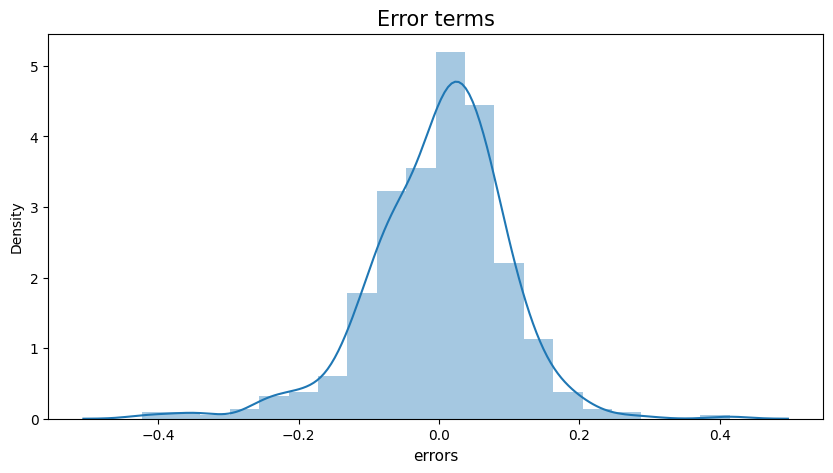

In [84]:
#plot histogram of error terms
fig=plt.figure()
plt.figure(figsize=(10,5))
sns.distplot((y_train-y_train_pred),bins=20)
plt.title('Error terms',fontsize=15)
plt.xlabel('errors',fontsize=11)
plt.show()


In [85]:
#How we can say data is normally distributed?

STEP 7 -- MAKING PREDICTION

In [86]:

from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()


In [87]:


#Create a list of numeric variables
num_vars=['temp','humidity','windspeed','count']

#Fit on data
data_test[num_vars] = scaler.fit_transform(data_test[num_vars])
data_test.head()

,spring,summer,winter,Aug,Dec,Feb,Jan,July,June,March,...,Wed,Cloudy,Mist,year,holiday,workingday,temp,humidity,windspeed,count
184,0,0,1,0,0,0,0,1,0,0,...,1,1,0,0,1,0,0.837241,0.534223,0.149393,0.704300
535,0,1,0,0,0,0,0,0,1,0,...,0,0,0,1,0,1,0.911423,0.470417,0.231142,0.725421
299,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0.496221,0.777843,0.443398,0.278853
221,0,0,1,1,0,0,0,0,0,0,...,0,0,0,0,0,1,0.890387,0.236659,0.449707,0.545512
152,0,1,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0.821739,0.070765,0.682387,0.569148


In [88]:
#Dividing into X_test and y_test
y_test = data_test.pop('count')
X_test = data_test
X_test.describe()

,spring,summer,winter,Aug,Dec,Feb,Jan,July,June,March,...,Tue,Wed,Cloudy,Mist,year,holiday,workingday,temp,humidity,windspeed
count,220.000000,220.000000,220.000000,220.000000,220.000000,220.000000,220.000000,220.000000,220.000000,220.000000,...,220.000000,220.000000,220.000000,220.000000,220.000000,220.000000,220.000000,220.000000,220.000000,220.000000
mean,0.254545,0.263636,0.245455,0.059091,0.086364,0.100000,0.077273,0.104545,0.095455,0.054545,...,0.122727,0.159091,0.318182,0.027273,0.481818,0.036364,0.640909,0.546074,0.508362,0.418803
std,0.436599,0.441609,0.431338,0.236333,0.281541,0.300684,0.267633,0.306665,0.294512,0.227609,...,0.328872,0.366595,0.466833,0.163248,0.500809,0.187620,0.480828,0.248645,0.200875,0.187683
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.329310,0.361079,0.284201
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.545492,0.491299,0.403318
75%,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.756414,0.650989,0.523975
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [89]:
X_train_new6.columns

Index(['spring', 'summer', 'July', 'Nov', 'Sep', 'Cloudy', 'Mist', 'year',
       'holiday', 'temp'],
      dtype='object')

In [90]:
# Now let's use our model to make predictions.

# Creating X_test_new dataframe by dropping variables from X_test
X_test_new = X_test[X_train_new6.columns]

# Adding a constant variable 

X_test_new1 = sm.add_constant(X_test_new)
X_test_new1.head()

,const,spring,summer,July,Nov,Sep,Cloudy,Mist,year,holiday,temp
184,1.0,0,0,1,0,0,1,0,0,1,0.837241
535,1.0,0,1,0,0,0,0,0,1,0,0.911423
299,1.0,0,0,0,0,0,1,0,0,0,0.496221
221,1.0,0,0,0,0,0,0,0,0,0,0.890387
152,1.0,0,1,0,0,0,0,0,0,0,0.821739


In [91]:
#making prediction
y_pred=lm6.predict(X_test_new1)

In [92]:
#finding r square

In [109]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

mean_squared_error(y_test,y_pred)                    

0.011467201847381625

In [110]:
mean_absolute_error(y_test,y_pred)

0.08282754085281496

In [111]:
rmse=np.sqrt(mean_squared_error(y_test,y_pred))
print(rmse)

0.10708502158276677


In [112]:
r2_score(y_test,y_pred)

0.7991686169344336

In [94]:
#Adjusted R^2
#adj r2=1-(1-R2)*(n-1)/(n-p-1)

#n =sample size , p = number of independent variables
n=X_test_new1.shape[0]
p=X_test_new1.shape[1]
Adj_r2=round(1-(1-0.7991686169344336)*(n-1)/(n-p-1),4)
print(Adj_r2)

0.7885


MODEL EVALUATION

Text(0, 0.5, 'y_pred')

<Figure size 640x480 with 0 Axes>

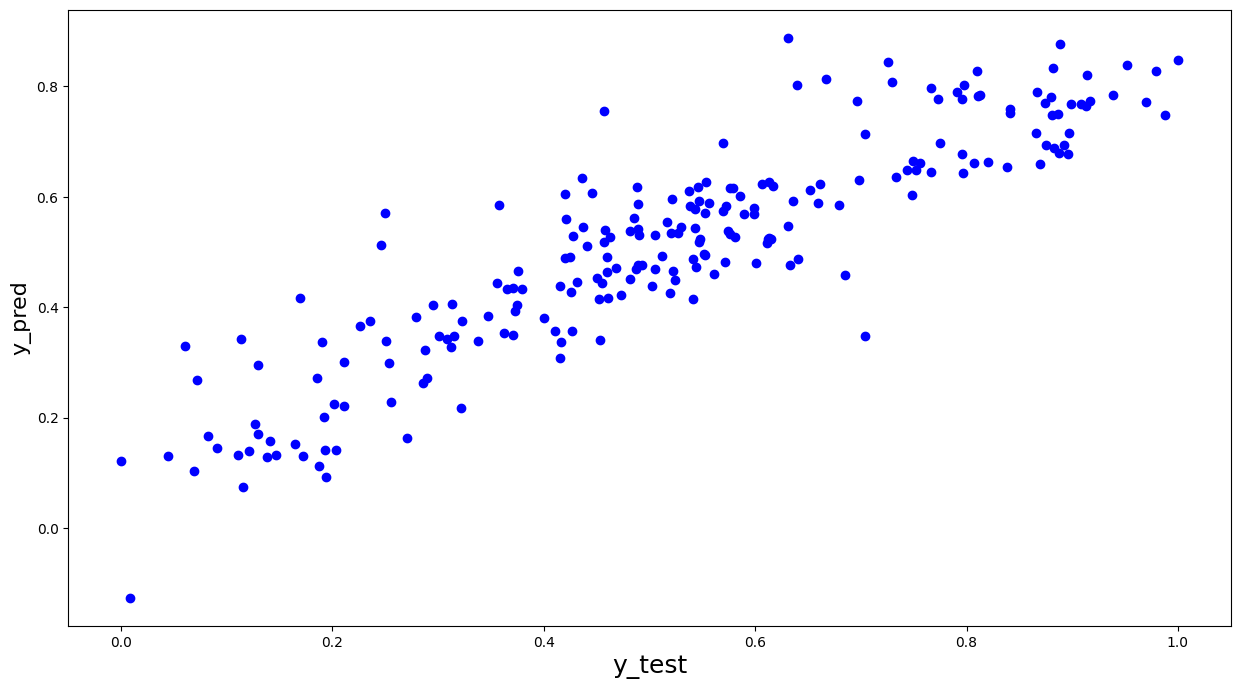

In [95]:
# Plotting y_test and y_pred to understand the spread.
fig = plt.figure()
plt.figure(figsize=(15,8))
plt.scatter(y_test,y_pred,color='blue')
fig.suptitle('y_test vs y_pred', fontsize=20)              # Plot heading 
plt.xlabel('y_test', fontsize=18)                          # X-label
plt.ylabel('y_pred', fontsize=16)                          # Y-label

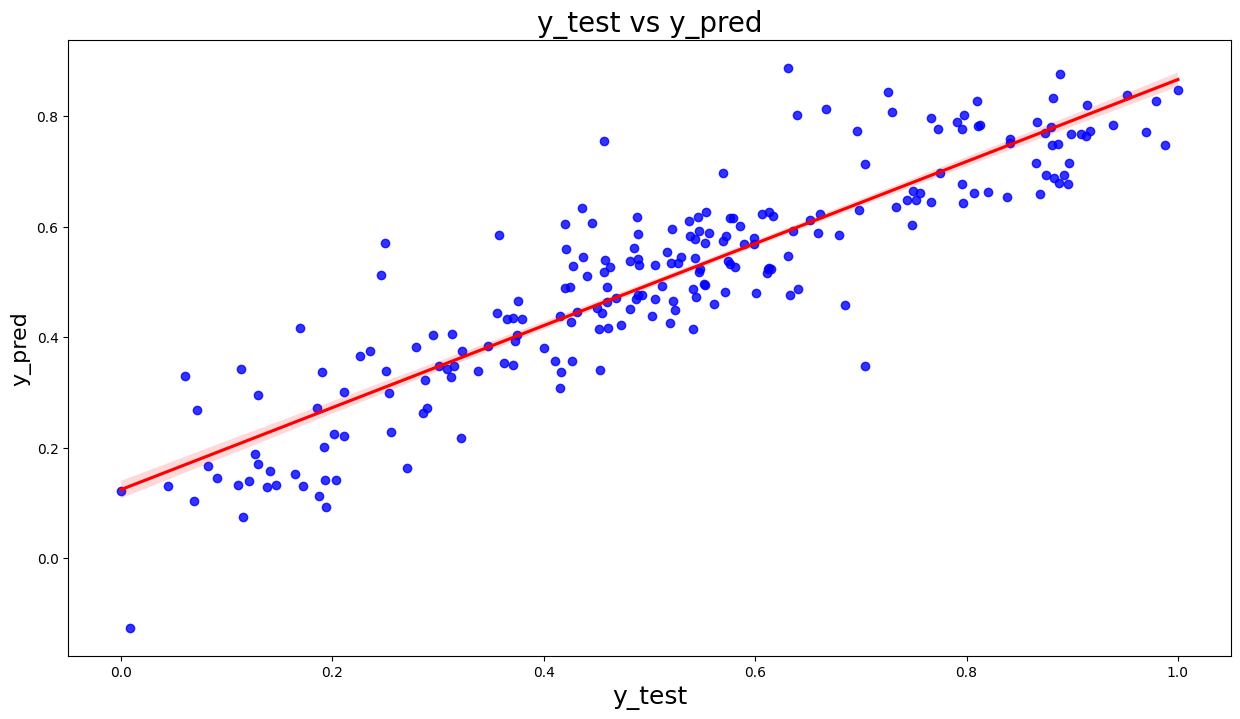

In [96]:
#Regression plot
plt.figure(figsize=(15,8))
sns.regplot(x=y_test, y=y_pred, ci=68, fit_reg=True,scatter_kws={"color": "blue"}, line_kws={"color": "red"})

plt.title('y_test vs y_pred', fontsize=20)              # Plot heading 
plt.xlabel('y_test', fontsize=18)                          # X-label
plt.ylabel('y_pred', fontsize=16)                          # Y-label
plt.show()

Final Result Comparison between Train model and Test:

Train R^2 : 0.816

Train Adjusted R^2 : 0.813

Test R^2:0.799

Test Adjusted R^2: 0.7885

Difference in R^2 between train and test: 2.105%

Difference in adjusted R^2 between Train and test: 3.05 % which is less than 5%

Yes! Its a best model




Interpretation:¶
- We arrived at a very decent model for the the demand for shared bikes with the significant variables
- We can see that temperature variable is having the highest coefficient 0.3986 , which means if the temperature increases by one unit the number of bike rentals increases by 0.3986  units.


Similary we can see coefficients of other variables in the equation for best fitted line.

We also see there are some variables with negative coefficients, A negative coefficient suggests that as the independent variable increases, the dependent variable tends to decrease. We have spring,summer,Nov,july,Cloudy,Mist,Holiday variables with negative coefficient. The coefficient value signifies how much the mean of the dependent variable changes given a one-unit shift in the independent variable while holding other variables in the model constant.

Business Goals:
- A US bike-sharing provider BoomBikes can focus more on Temperature
- We can see demand for bikes was more in 2019 than 2018, so just focus as there is increase in 2019 and might be facing dips in their revenues due to the ongoing Corona pandemic and by the time it reduces the things will be better
- Can focus more on Summer & spring season, july, nov month, Weekends, holidays as they have good influence on bike rentals.
- We can see summer season has negative coefficients and negatively correlated to bike rentals. So we can give some offers there to increase the demand
- Now seeing to weathersit variable, we have got negative coefficients for Mist and Cloudy weather... And yes we can give offers